> Tensorflow Documentation - https://www.tensorflow.org/api_docs/python/

UV is An extremely fast Python package and project manager, faster 10-100x time than pip.
Installing UV, setting Up Virtual Environment and downloading depending dependencies.

```sh
pip install uv
uv venv --python 3.10
uv pip install -r requirements.txt
```

In [23]:
import tensorflow as tf # models
import pandas as pd # reading & processing
import seaborn as sns #visualization
from tensorflow.keras.layers import Normalization, Dense, InputLayer
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber

# Building Neural Networks [Car Price Prediction]

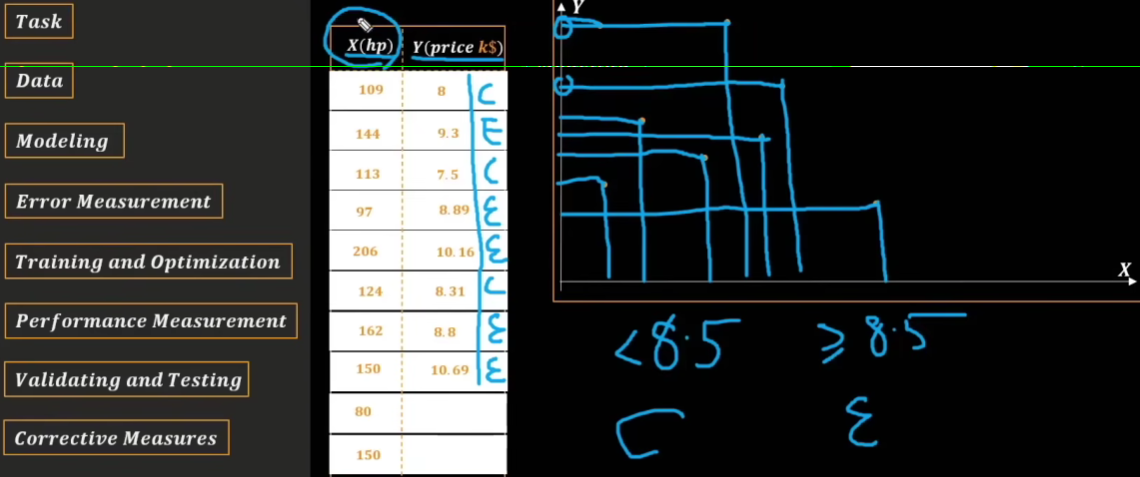
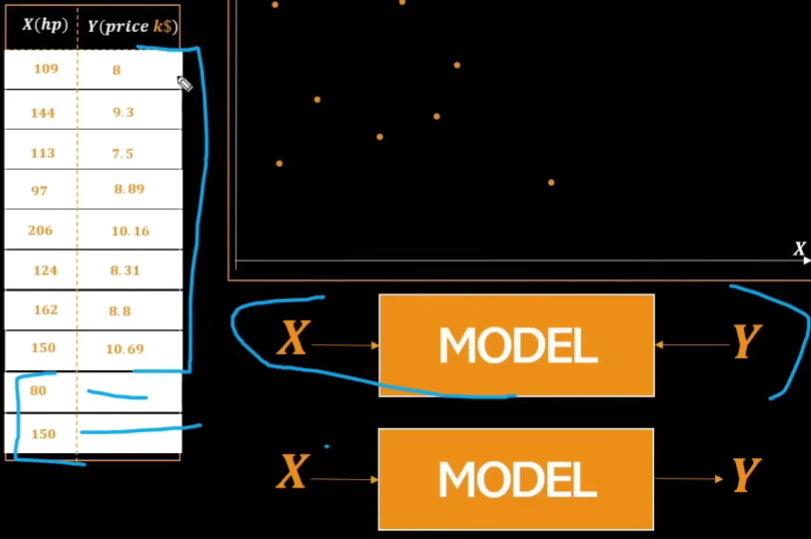
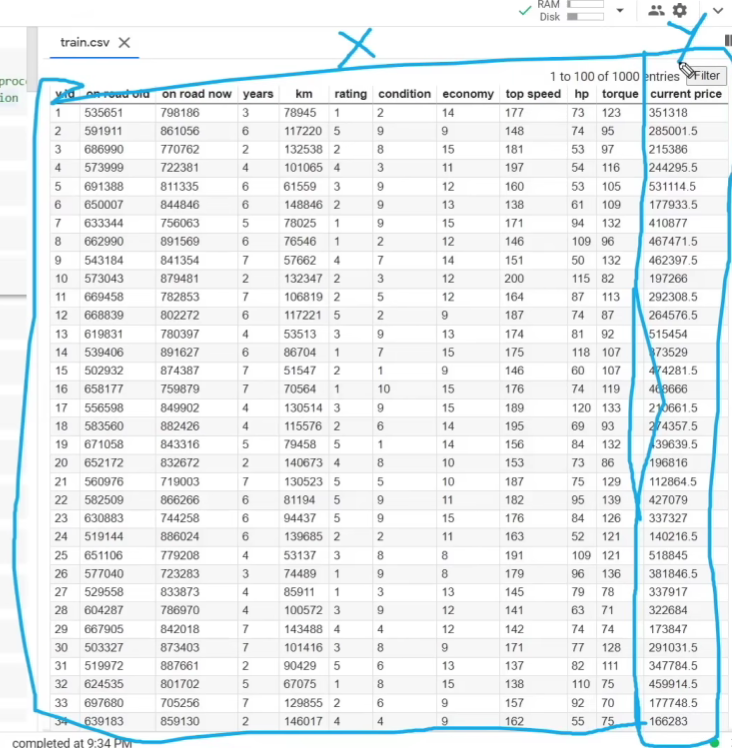

## Data Preparation

In [4]:
data = pd.read_csv("train.csv", sep = ",")

In [5]:
data.head()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [6]:
data.shape

(1000, 12)

seaborn documentation - https://seaborn.pydata.org/generated/seaborn.pairplot.html

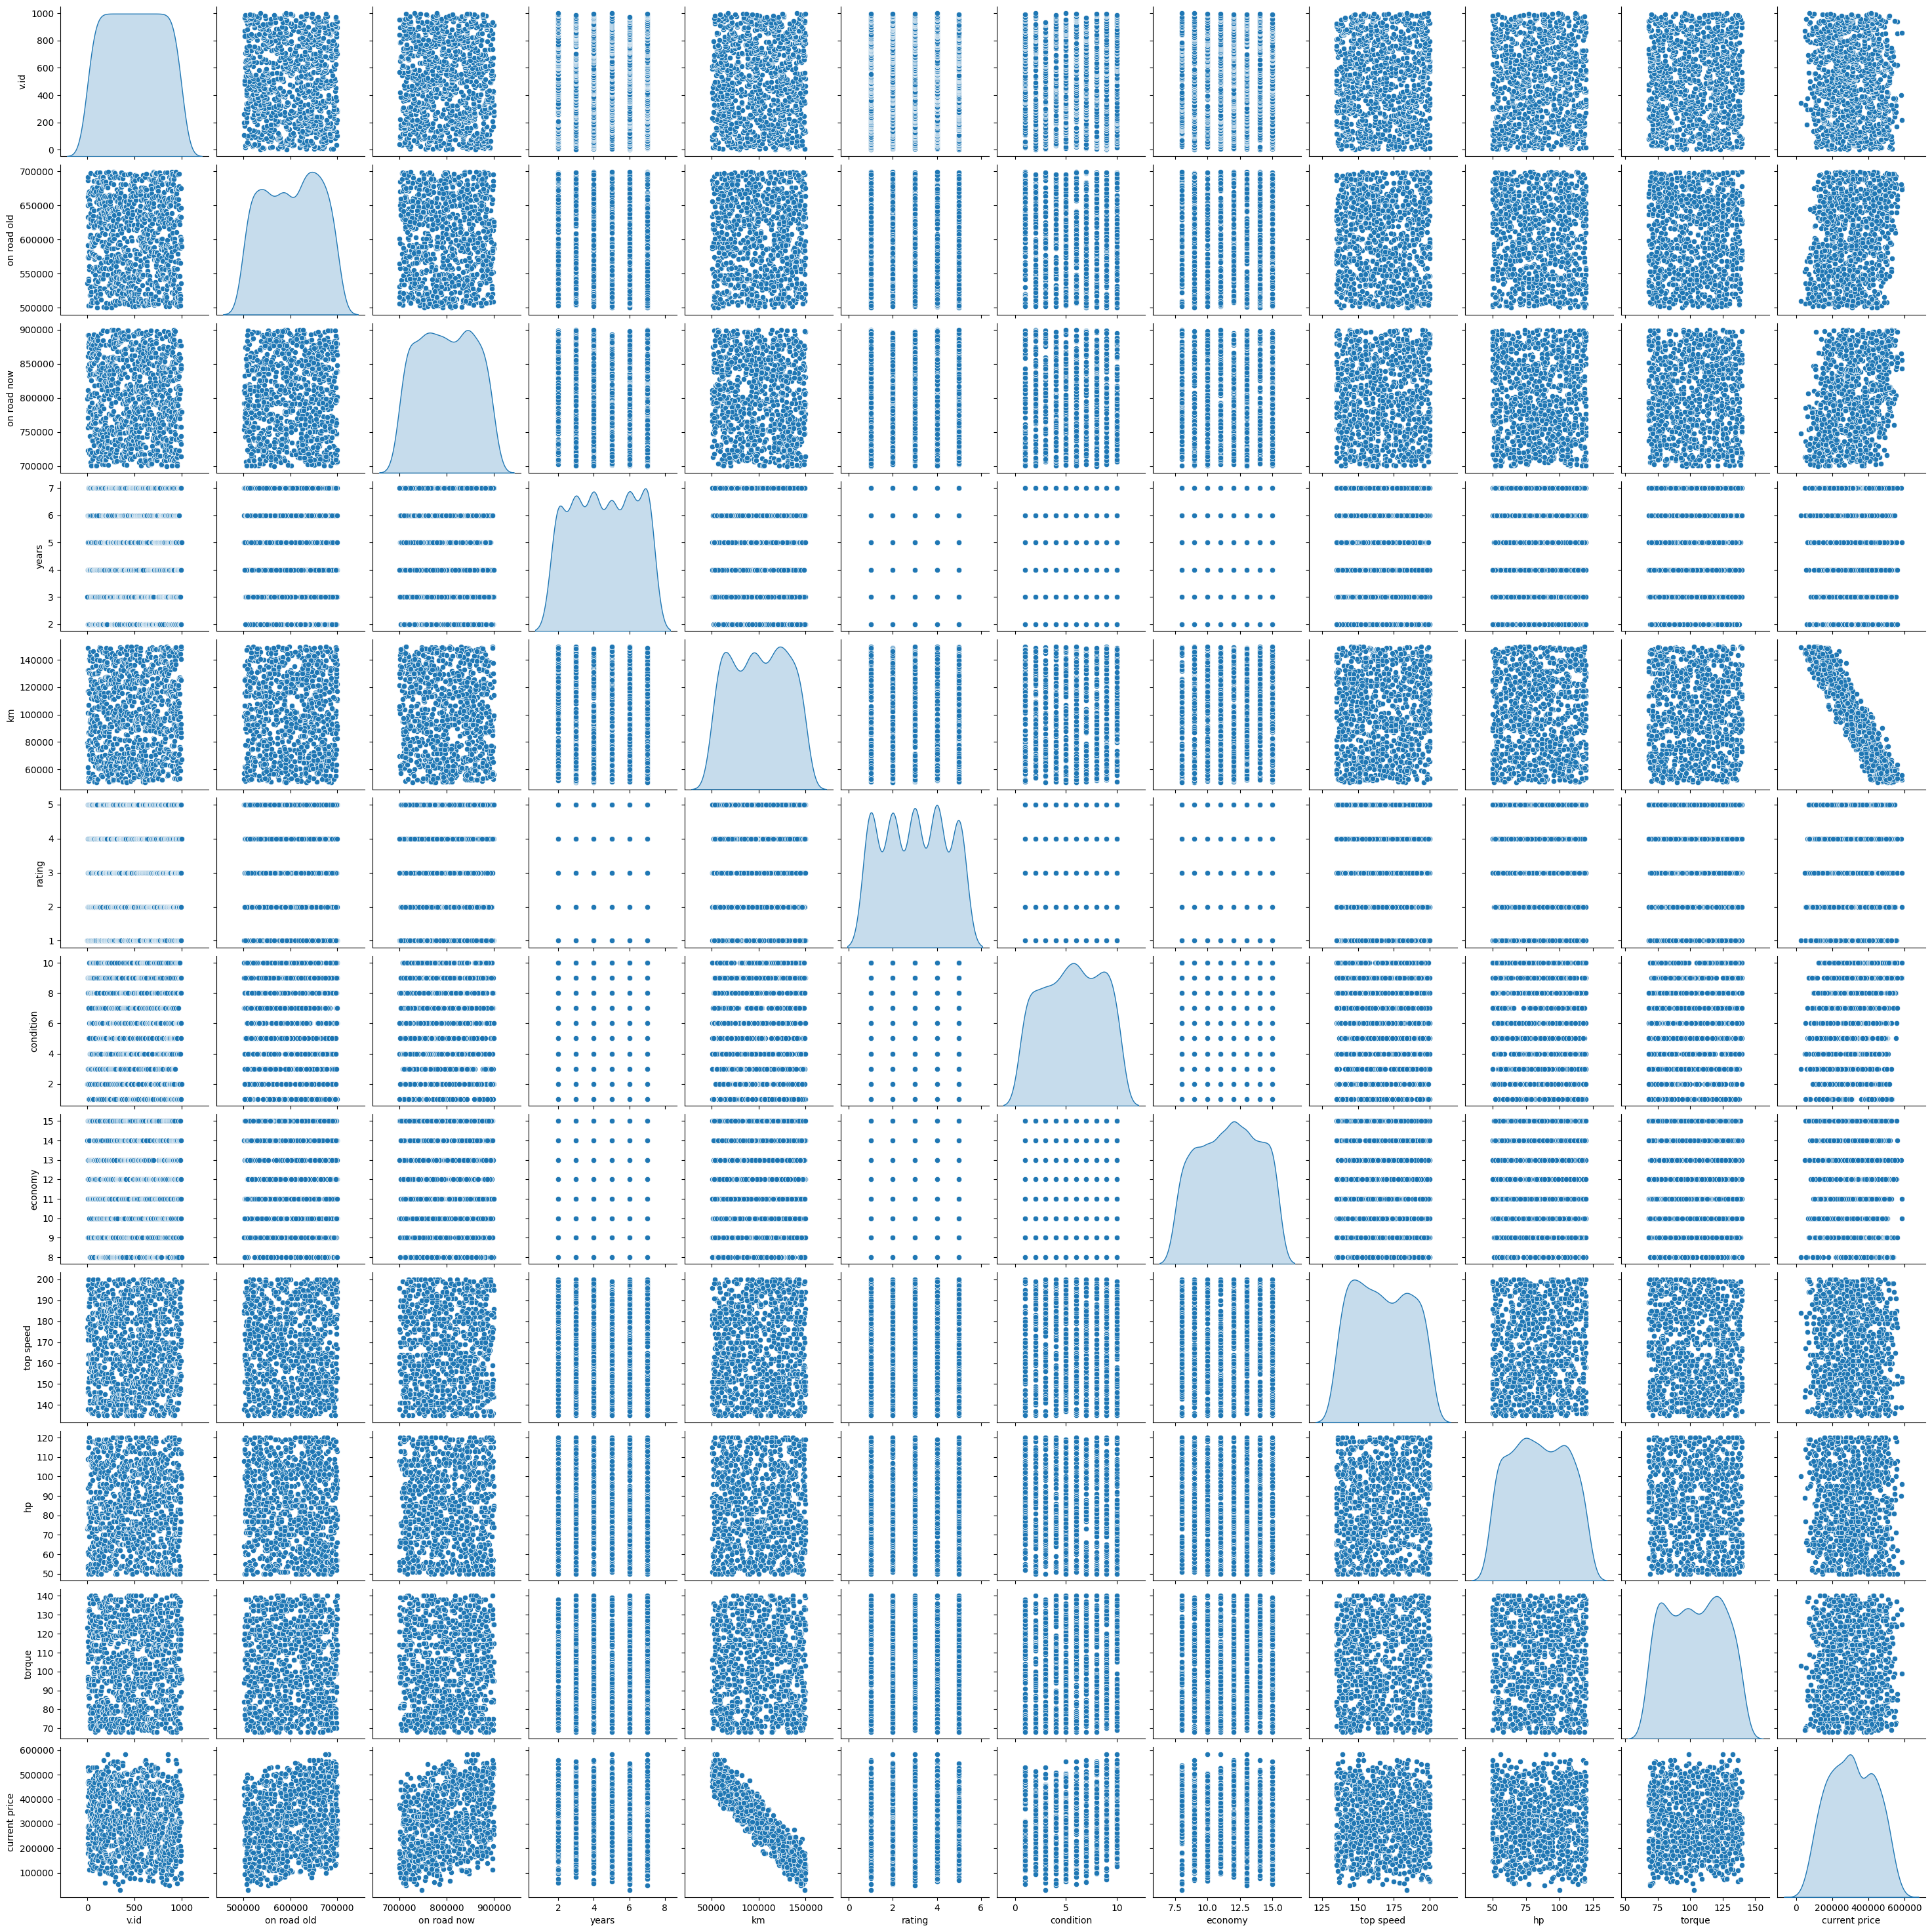

In [7]:
sns.pairplot(data[['v.id','on road old','on road now','years','km','rating','condition','economy','top speed','hp','torque','current price']], diag_kind='kde')

In [8]:
tensor_data = tf.constant(data)
tensor_data = tf.cast(tensor_data, tf.float32)
print(tensor_data)

tf.Tensor(
[[1.000000e+00 5.356510e+05 7.981860e+05 ... 7.300000e+01 1.230000e+02
  3.513180e+05]
 [2.000000e+00 5.919110e+05 8.610560e+05 ... 7.400000e+01 9.500000e+01
  2.850015e+05]
 [3.000000e+00 6.869900e+05 7.707620e+05 ... 5.300000e+01 9.700000e+01
  2.153860e+05]
 ...
 [9.980000e+02 6.463440e+05 8.427330e+05 ... 1.130000e+02 8.900000e+01
  4.058710e+05]
 [9.990000e+02 5.355590e+05 7.324390e+05 ... 1.120000e+02 1.280000e+02
  7.439800e+04]
 [1.000000e+03 5.901050e+05 7.797430e+05 ... 9.900000e+01 9.600000e+01
  4.149385e+05]], shape=(1000, 12), dtype=float32)


In [9]:
# Randomly shuffle the data to remove any bias
tensor_data = tf.random.shuffle(tensor_data)
print(tensor_data[:5])

tf.Tensor(
[[9.240000e+02 5.072720e+05 7.234230e+05 7.000000e+00 1.332510e+05
  4.000000e+00 3.000000e+00 1.300000e+01 1.990000e+02 1.020000e+02
  1.090000e+02 7.486300e+04]
 [3.860000e+02 6.960060e+05 8.908230e+05 7.000000e+00 1.001880e+05
  4.000000e+00 4.000000e+00 1.400000e+01 1.430000e+02 9.100000e+01
  1.170000e+02 3.855565e+05]
 [1.110000e+02 5.747560e+05 8.907700e+05 5.000000e+00 6.116000e+04
  3.000000e+00 6.000000e+00 9.000000e+00 1.670000e+02 6.500000e+01
  1.060000e+02 4.907795e+05]
 [5.530000e+02 6.704880e+05 8.311100e+05 6.000000e+00 1.180130e+05
  1.000000e+00 6.000000e+00 1.400000e+01 1.510000e+02 6.200000e+01
  8.300000e+01 2.789935e+05]
 [6.020000e+02 6.739200e+05 7.169720e+05 2.000000e+00 7.331300e+04
  4.000000e+00 1.000000e+01 1.300000e+01 1.640000e+02 5.300000e+01
  9.600000e+01 4.529310e+05]], shape=(5, 12), dtype=float32)


In [10]:
X = tensor_data[:, 3:-1]
X.shape

TensorShape([1000, 8])

In [11]:
X[:5]

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[7.00000e+00, 1.33251e+05, 4.00000e+00, 3.00000e+00, 1.30000e+01,
        1.99000e+02, 1.02000e+02, 1.09000e+02],
       [7.00000e+00, 1.00188e+05, 4.00000e+00, 4.00000e+00, 1.40000e+01,
        1.43000e+02, 9.10000e+01, 1.17000e+02],
       [5.00000e+00, 6.11600e+04, 3.00000e+00, 6.00000e+00, 9.00000e+00,
        1.67000e+02, 6.50000e+01, 1.06000e+02],
       [6.00000e+00, 1.18013e+05, 1.00000e+00, 6.00000e+00, 1.40000e+01,
        1.51000e+02, 6.20000e+01, 8.30000e+01],
       [2.00000e+00, 7.33130e+04, 4.00000e+00, 1.00000e+01, 1.30000e+01,
        1.64000e+02, 5.30000e+01, 9.60000e+01]], dtype=float32)>

In [12]:
y = tensor_data[:, -1]
y = tf.expand_dims(y, axis = -1)
y[:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[ 74863. ],
       [385556.5],
       [490779.5],
       [278993.5],
       [452931. ]], dtype=float32)>

In [13]:
'''
tf.keras.layers.Normalization - A preprocessing layer that normalizes continuous features.

Applies formula of (input - mean) / Standard Deviation
where S.D. = square root of variance
'''

x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8]])
normalizer = Normalization(axis = -1, mean = 5, variance = 4) # Just taking as example, the parameters
normalizer(x_normalized) # Using axis = -1, means we have to use the innermost dimension which has these 5 features each, rather than axis = 0 having batch size = 2.

<tf.Tensor: shape=(2, 5), dtype=float32, numpy=
array([[-1. , -0.5,  0. ,  0.5,  1. ],
       [-0.5,  0. ,  0.5,  1. ,  1.5]], dtype=float32)>

In [14]:
# Rather than manually setting up mean and variance, tensorflow can smartly calculate on its own

x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8]])
normalizer = Normalization()
normalizer.adapt(x_normalized) # During adapt(), the layer will compute a mean and variance separately for each position in each axis specified by the axis argument.
normalizer(x_normalized)

# Eg- For Column 1, mean is 3.5, for next column 4.5 and so on the mean and variance will be calcuted differently for each column

<tf.Tensor: shape=(2, 5), dtype=float32, numpy=
array([[-1., -1., -1., -1., -1.],
       [ 1.,  1.,  1.,  1.,  1.]], dtype=float32)>

In [15]:
x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8], [32,1,56,3,5]])
normalizer.adapt(x_normalized)
normalizer(x_normalized)

<tf.Tensor: shape=(3, 5), dtype=float32, numpy=
array([[-0.7439795 ,  0.39223233, -0.72800297,  0.3922322 ,  0.2672614 ],
       [-0.6695816 ,  0.98058075, -0.6860028 ,  0.9805806 ,  1.0690452 ],
       [ 1.4135611 , -1.3728129 ,  1.4140056 , -1.3728131 , -1.3363061 ]],
      dtype=float32)>

In [16]:
normalizer = Normalization()
normalizer.adapt(X)
normalizer(X)[:5]

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[ 1.4194926 ,  1.1318201 ,  0.7217796 , -0.9181603 ,  0.6167485 ,
         1.66541   ,  0.8511374 ,  0.26496363],
       [ 1.4194926 , -0.00296617,  0.7217796 , -0.5639318 ,  1.065293  ,
        -1.2393453 ,  0.31472683,  0.6450439 ],
       [ 0.2554971 , -1.3424828 ,  0.00855871,  0.14452523, -1.177429  ,
         0.00554988, -0.9531527 ,  0.12243352],
       [ 0.83749485,  0.6088224 , -1.417883  ,  0.14452523,  1.065293  ,
        -0.8243802 , -1.0994465 , -0.9702973 ],
       [-1.4904962 , -0.9253683 ,  0.7217796 ,  1.5614393 ,  0.6167485 ,
        -0.15006201, -1.5383279 , -0.35266683]], dtype=float32)>

In [17]:
X[:5]

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[7.00000e+00, 1.33251e+05, 4.00000e+00, 3.00000e+00, 1.30000e+01,
        1.99000e+02, 1.02000e+02, 1.09000e+02],
       [7.00000e+00, 1.00188e+05, 4.00000e+00, 4.00000e+00, 1.40000e+01,
        1.43000e+02, 9.10000e+01, 1.17000e+02],
       [5.00000e+00, 6.11600e+04, 3.00000e+00, 6.00000e+00, 9.00000e+00,
        1.67000e+02, 6.50000e+01, 1.06000e+02],
       [6.00000e+00, 1.18013e+05, 1.00000e+00, 6.00000e+00, 1.40000e+01,
        1.51000e+02, 6.20000e+01, 8.30000e+01],
       [2.00000e+00, 7.33130e+04, 4.00000e+00, 1.00000e+01, 1.30000e+01,
        1.64000e+02, 5.30000e+01, 9.60000e+01]], dtype=float32)>

## Linear Regression Model

In [18]:
# tf.keras.Sequential - Sequential groups a linear stack of layers into a Model.
# tf.keras.layers.Dense - Just your regular densely-connected NN layer.

model = tf.keras.Sequential([
    InputLayer(shape = (8,)), # where batch = 8
    normalizer,
    Dense(1) # Dense layer
])
model.build((None, 8)) # 8 weights + 1 bias = 0 trainable params
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (108.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 17 (72.00 B)

In [19]:
import os
# This dynamically adds Graphviz to the PATH just for this Python session
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

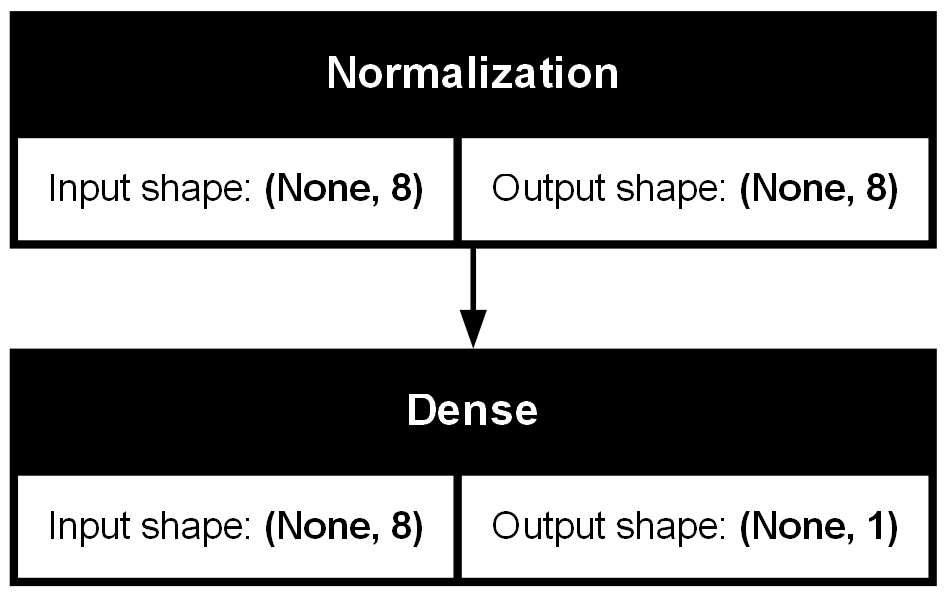

In [20]:
tf.keras.utils.plot_model(model, to_file = "model.png", show_shapes = True)

## Error Sanctioning

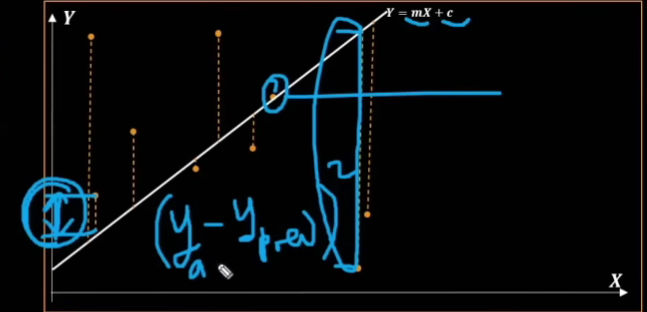

Absolute Error is preferred over MSE when outlier is like this: <br>
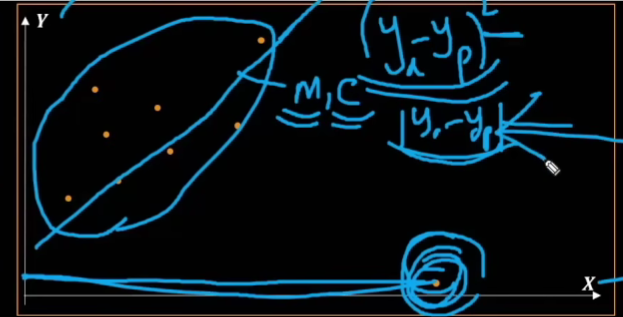

MSE, MAE, Hubber Loss: <br>
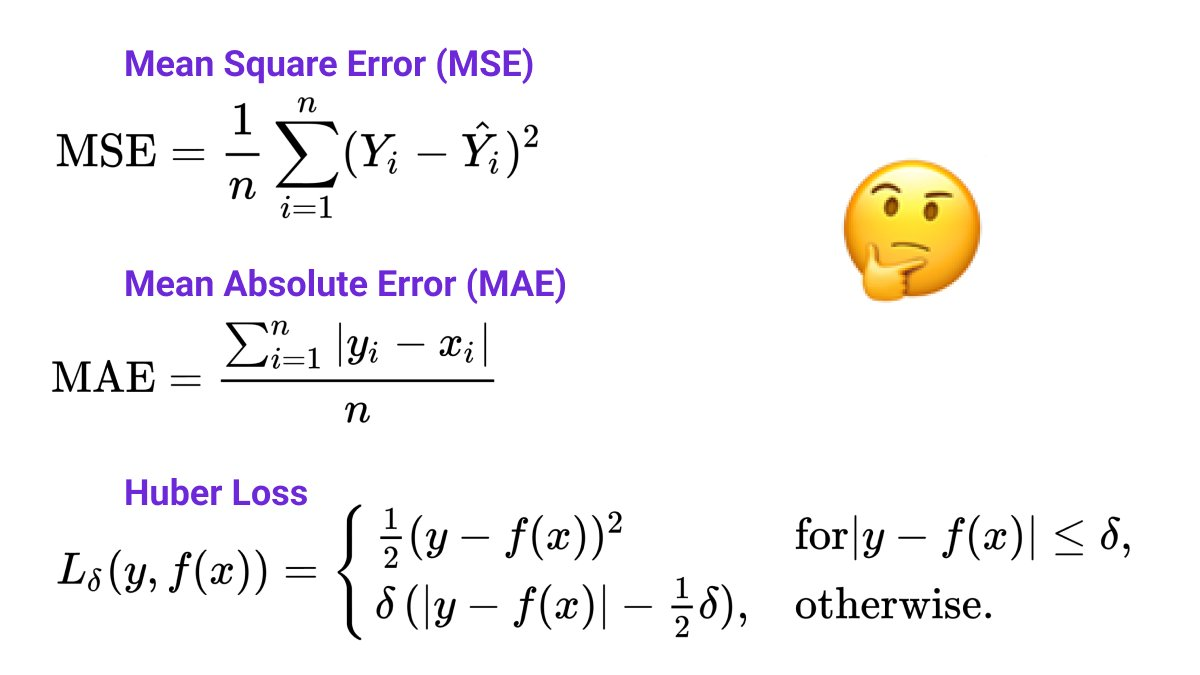

In [28]:
# tf.keras.losses.MeanSquaredError - Computes the mean of squares of errors between labels and predictions.

model.compile(loss = MeanSquaredError())

In [29]:
# tf.keras.losses.MeanAbsoluteError - Computes the mean of absolute difference between labels and predictions.

model.compile(loss = MeanAbsoluteError())

In [ ]:
# tf.keras.losses.Huber - Computes the Huber loss between y_true & y_pred.

model.compile(loss = Huber())

## Training & Optimization